# AG2 - Actividad Guiada 2
Nombre: Marcos Galvez Santamaría <br>
Link:   https://colab.research.google.com/drive/1uHcm5k5FMlMLrFze_XXerVjlrTygQXQx <br>
Github: https://github.com/marcosgalvez14/03MIAR-Algoritmos-De-Optimizacion
<br>

In [1]:
import math

## Programación Dinámica. Viaje por el rio
* **Definición**: Es posible dividir el problema en subproblemas más pequeños, guardando las soluciones para ser utilizadas más adelante.
* **Características** que permiten identificar problemas aplicables:<br>
  -Es posible almacenar soluciones de los subproblemas para ser utilizados más adelante<br>
  -Debe verificar el principio de optimalidad de Bellman: “en una secuencia optima de decisiones, toda sub-secuencia también es óptima” (*)<br>
  -La necesidad de guardar la información acerca de las soluciones parciales unido a la recursividad provoca la necesidad de preocuparnos por la complejidad espacial (cuantos recursos de espacio usaremos)<br>

### Problema<br>
En un río hay **n** embarcaderos y debemos desplazarnos río abajo desde un embarcadero a otro. Cada embarcadero tiene precios diferentes para ir de un embarcadero a otro situado más abajo. Para ir del embarcadero i al j, puede ocurrir que sea más barato hacer un trasbordo por un embarcadero intermedio k. El problema consiste en determinar la combinación más barata.

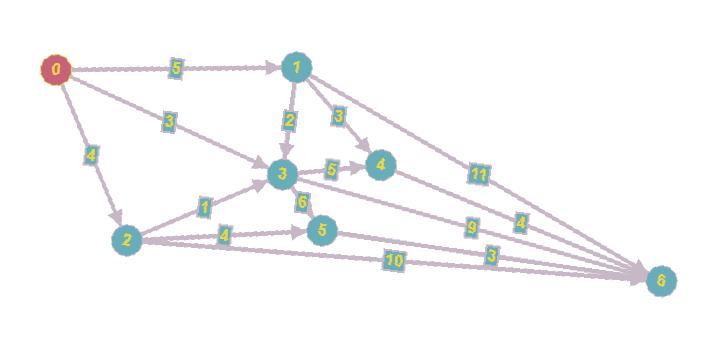

*Consideramos una tabla TARIFAS(i,j) para almacenar todos los precios que nos ofrecen los embarcaderos.<br>
*Si no es posible ir desde i a j daremos un valor alto para garantizar que ese trayecto no se va a elegir en la ruta óptima(modelado habitual para restricciones)

In [2]:
#Viaje por el rio - Programación dinámica
################################################################################

TARIFAS = [
[0,5,4,3,float("inf"),999,999],   #desde nodo 0
[999,0,999,2,3,999,11],  #desde nodo 1
[999,999, 0,1,999,4,10], #desde nodo 2
[999,999,999, 0,5,6,9],
[999,999, 999,999,0,999,4],
[999,999, 999,999,999,0,3],
[999,999,999,999,999,999,0]
]

#999 se puede sustituir por float("inf") del modulo math
TARIFAS

[[0, 5, 4, 3, inf, 999, 999],
 [999, 0, 999, 2, 3, 999, 11],
 [999, 999, 0, 1, 999, 4, 10],
 [999, 999, 999, 0, 5, 6, 9],
 [999, 999, 999, 999, 0, 999, 4],
 [999, 999, 999, 999, 999, 0, 3],
 [999, 999, 999, 999, 999, 999, 0]]

In [3]:
#Calculo de la matriz de PRECIOS y RUTAS
#  PRECIOS - contiene la matriz del mejor precio para ir de un nodo a otro
#  RUTAS   - contiene los nodos intermedios para ir de un nodo a otro
################################################################
def Precios(TARIFAS):
################################################################
  #Total de Nodos
  N = len(TARIFAS[0])

  #Inicialización de la tabla de precios
  PRECIOS = [ [9999]*N for i in [9999]*N]  #n x n
  RUTA = [ [""]*N for i in [""]*N]

  #Se recorren todos los nodos con dos bucles(origen - destino)
  #  para ir construyendo la matriz de PRECIOS
  for i in range(N-1):
    for j in range(i+1, N):

      # Asumimos que el mínimo es la tarifa de un nodo a otro inicialmente
      MIN = TARIFAS[i][j]
      print("La tarifa desde " + str(i) + " hasta " + str(j) + " con un precio de " + str(TARIFAS[i][j]))

      # Asumimos que la mejor ruta de un nodo a otro comienza en el nodo inicial (ej: 0,1 -> 0, 0,4 -> 0, 2,5 -> 2)
      RUTA[i][j] = i

      # Recorremos posibles movimientos intermedios
      for k in range(i, j):

         # Si el precio de ir de i a k más la tarifa de k a j es menor que la tarifa de i a j, nos quedamos con esa ruta
        if PRECIOS[i][k] + TARIFAS[k][j] < MIN:
            MIN = min(MIN, PRECIOS[i][k] + TARIFAS[k][j] )
            RUTA[i][j] = k
            print("Ruta indirecta identificada desde " + str(i) + " hasta " + str(j) + " pasando por " + str(k) + " con un precio de " + str(MIN))

        # Actualizamos precio de i a j como el mínimo (puede ser pasando por k)
        PRECIOS[i][j] = MIN

  return PRECIOS,RUTA

In [4]:
PRECIOS,RUTA = Precios(TARIFAS)
#print(PRECIOS[0][6])

print("PRECIOS")
for i in range(len(TARIFAS)):
  print(PRECIOS[i])

print("\nRUTA")
for i in range(len(TARIFAS)):
  print(RUTA[i])

La tarifa desde 0 hasta 1 con un precio de 5
La tarifa desde 0 hasta 2 con un precio de 4
La tarifa desde 0 hasta 3 con un precio de 3
La tarifa desde 0 hasta 4 con un precio de inf
Ruta indirecta identificada desde 0 hasta 4 pasando por 1 con un precio de 8
La tarifa desde 0 hasta 5 con un precio de 999
Ruta indirecta identificada desde 0 hasta 5 pasando por 2 con un precio de 8
La tarifa desde 0 hasta 6 con un precio de 999
Ruta indirecta identificada desde 0 hasta 6 pasando por 1 con un precio de 16
Ruta indirecta identificada desde 0 hasta 6 pasando por 2 con un precio de 14
Ruta indirecta identificada desde 0 hasta 6 pasando por 3 con un precio de 12
Ruta indirecta identificada desde 0 hasta 6 pasando por 5 con un precio de 11
La tarifa desde 1 hasta 2 con un precio de 999
La tarifa desde 1 hasta 3 con un precio de 2
La tarifa desde 1 hasta 4 con un precio de 3
La tarifa desde 1 hasta 5 con un precio de 999
Ruta indirecta identificada desde 1 hasta 5 pasando por 3 con un precio de

In [5]:
#Calculo de la ruta usando la matriz RUTA
def calcular_ruta(RUTA, desde, hasta):
  if desde == RUTA[desde][hasta]:
  #if desde == hasta:
    #print("Ir a :" + str(desde))
    return desde
  else:
    return str(calcular_ruta(RUTA, desde, RUTA[desde][hasta])) +  ',' + str(RUTA[desde][hasta])

print("\nLa ruta es:")
calcular_ruta(RUTA, 0,6)


La ruta es:


'0,2,5'

## Problema de Asignacion de tarea

In [6]:
#Asignacion de tareas - Ramificación y Poda
################################################################################
#    T A R E A
#   A
#   G
#   E
#   N
#   T
#   E

COSTES=[[11,12,18,40],
        [14,15,13,22],
        [11,17,19,23],
        [17,14,20,28]]


In [7]:
#Calculo del valor de una solucion parcial
def valor(S,COSTES):
  VALOR = 0
  for i in range(len(S)):
    VALOR += COSTES[S[i]][i]
  return VALOR

valor((3,2,  ),COSTES)

34

In [8]:
#Coste inferior para soluciones parciales
#  (1,3,) Se asigna la tarea 1 al agente 0 y la tarea 3 al agente 1

def CI(S,COSTES):
    # Calculo el coste parcial de la solución dada
    coste = valor(S,COSTES)

    # Calculo coste mínimo de opciones restantes no usadas permitiendo reutilización por sencillez (relajación = menos poda)
    no_usadas = set(range(len(COSTES)))-set(S)

    for i in range(len(S),len(COSTES)):
        coste += min([COSTES[i][j] for j in no_usadas])

    return coste

def CS(S,COSTES):
    # Calculo el coste parcial de la solución dada
    coste = valor(S,COSTES)

    # Calculo coste máximo de opciones restantes no usadas
    no_usadas = set(range(len(COSTES)))-set(S)

    for i in range(len(S),len(COSTES)):
      coste += max([COSTES[i][j] for j in no_usadas])

    return coste

CI((0,1),COSTES)

65

In [9]:
#Genera tantos hijos como como posibilidades haya para la siguiente elemento de la tupla
#(0,) -> (0,1), (0,2), (0,3)
def crear_hijos(NODO, N):
  HIJOS = []
  for i in range(N):
    if i not in NODO:
      HIJOS.append({'s':NODO +(i,)    })
  return HIJOS

In [10]:
crear_hijos((0,) , 4)

[{'s': (0, 1)}, {'s': (0, 2)}, {'s': (0, 3)}]

In [12]:
def ramificacion_y_poda(COSTES):
#Construccion iterativa de soluciones(arbol). En cada etapa asignamos un agente(ramas).
#Nodos del grafo  { s:(1,2),CI:3,CS:5  }
  print(COSTES)
  DIMENSION = len(COSTES)
  MEJOR_SOLUCION=tuple( i for i in range(len(COSTES)) )
  CotaSup = valor(MEJOR_SOLUCION,COSTES)
  print("Cota Superior:", CotaSup)

  NODOS=[]
  NODOS.append({'s':(), 'ci':CI((),COSTES)    } )

  iteracion = 0

  while( len(NODOS) > 0):
    iteracion +=1

    nodo_prometedor = [ min(NODOS, key=lambda x:x['ci']) ][0]['s']
    print("Nodo prometedor:", nodo_prometedor)

    #Ramificacion
    #Se generan los hijos
    HIJOS =[ {'s':x['s'], 'ci':CI(x['s'], COSTES)   } for x in crear_hijos(nodo_prometedor, DIMENSION) ]
    print("Explorando hijos:")
    print(HIJOS)

    #Revisamos la cota superior y nos quedamos con la mejor solucion si llegamos a una solucion final
    NODO_FINAL = [x for x in HIJOS if len(x['s']) == DIMENSION  ]
    if len(NODO_FINAL ) >0:
      print("\n********Soluciones:",  [x for x in HIJOS if len(x['s']) == DIMENSION  ] )
      if NODO_FINAL[0]['ci'] < CotaSup:
        CotaSup = NODO_FINAL[0]['ci']
        MEJOR_SOLUCION = NODO_FINAL

    #Poda
    HIJOS = [x for x in HIJOS if x['ci'] < CotaSup   ]
    print("Despues de la poda:")
    print(HIJOS)

    #Añadimos los hijos
    NODOS.extend(HIJOS)

    #Eliminamos el nodo ramificado
    NODOS =  [  x for x in NODOS if x['s'] != nodo_prometedor    ]
    print("NODOS a explorar: ")
    print(NODOS)

  print("La solucion final es:" ,MEJOR_SOLUCION , " en " , iteracion , " iteraciones" , " para dimension: " ,DIMENSION  )



ramificacion_y_poda(COSTES)

[[11, 12, 18, 40], [14, 15, 13, 22], [11, 17, 19, 23], [17, 14, 20, 28]]
Cota Superior: 73
Nodo prometedor: ()
Explorando hijos:
[{'s': (0,), 'ci': 55}, {'s': (1,), 'ci': 55}, {'s': (2,), 'ci': 50}, {'s': (3,), 'ci': 55}]
Despues de la poda:
[{'s': (0,), 'ci': 55}, {'s': (1,), 'ci': 55}, {'s': (2,), 'ci': 50}, {'s': (3,), 'ci': 55}]
NODOS a explorar: 
[{'s': (0,), 'ci': 55}, {'s': (1,), 'ci': 55}, {'s': (2,), 'ci': 50}, {'s': (3,), 'ci': 55}]
Nodo prometedor: (2,)
Explorando hijos:
[{'s': (2, 0), 'ci': 54}, {'s': (2, 1), 'ci': 54}, {'s': (2, 3), 'ci': 50}]
Despues de la poda:
[{'s': (2, 0), 'ci': 54}, {'s': (2, 1), 'ci': 54}, {'s': (2, 3), 'ci': 50}]
NODOS a explorar: 
[{'s': (0,), 'ci': 55}, {'s': (1,), 'ci': 55}, {'s': (3,), 'ci': 55}, {'s': (2, 0), 'ci': 54}, {'s': (2, 1), 'ci': 54}, {'s': (2, 3), 'ci': 50}]
Nodo prometedor: (2, 3)
Explorando hijos:
[{'s': (2, 3, 0), 'ci': 57}, {'s': (2, 3, 1), 'ci': 55}]
Despues de la poda:
[{'s': (2, 3, 0), 'ci': 57}, {'s': (2, 3, 1), 'ci': 55}]
N

## Descenso del gradiente

In [13]:
import math                      #Funciones matematicas
import matplotlib.pyplot as plt  #Generacion de gráficos (otra opcion seaborn)
import numpy as np               #Tratamiento matriz N-dimensionales y otras (fundamental!)
#import scipy as sc

import random

Vamos a buscar el minimo de la funcion paraboloide : $$f(x) =  x² + y²$$

Obviamente se encuentra en (x,y)=(0,0) pero probaremos como llegamos a él a través del descenso del gradiante.

In [14]:
#Definimos la funcion
#Paraboloide
f  = lambda X:      X[0]**2 + X[1]**2    #Funcion
df = lambda X: [2*X[0] , 2*X[1]]         #Gradiente

df([1,2])

[2, 4]

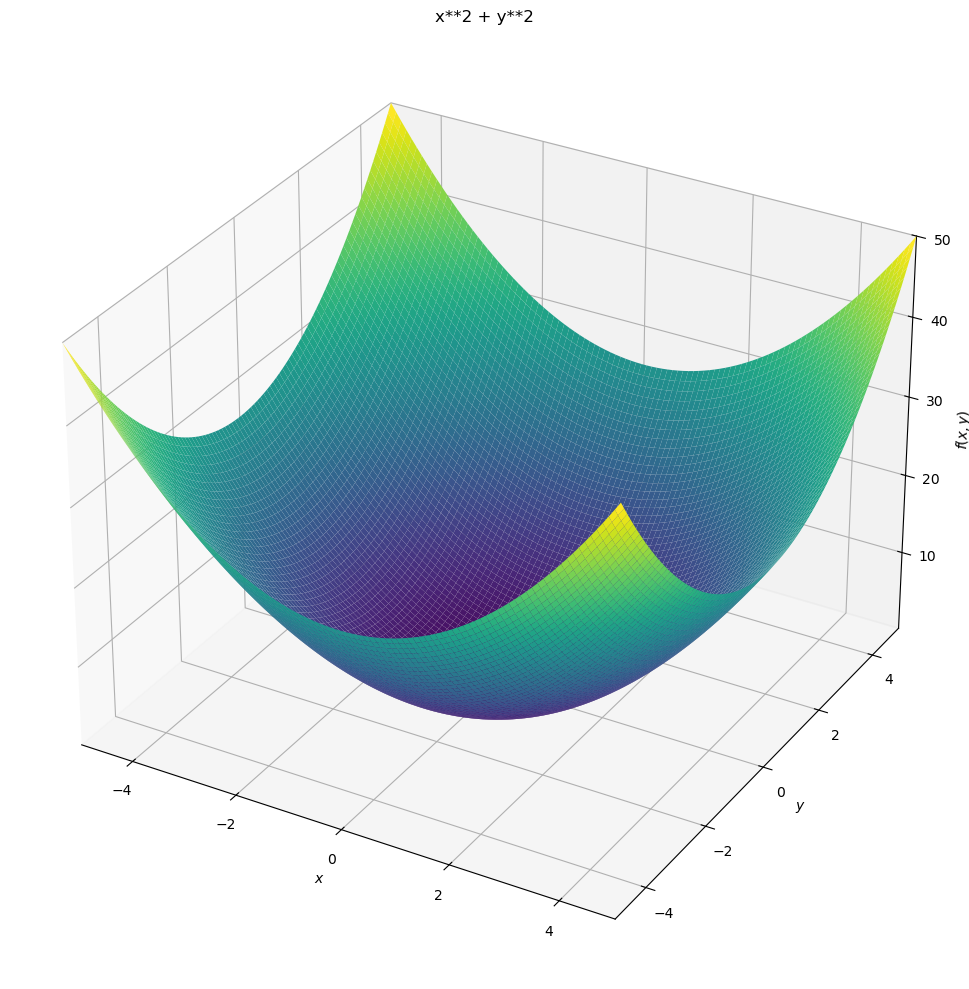

In [15]:
from sympy import symbols
from sympy.plotting import plot
from sympy.plotting import plot3d
x,y = symbols('x y')
plot3d(x**2 + y**2,
       (x,-5,5),(y,-5,5),
       title='x**2 + y**2',
       size=(10,10))

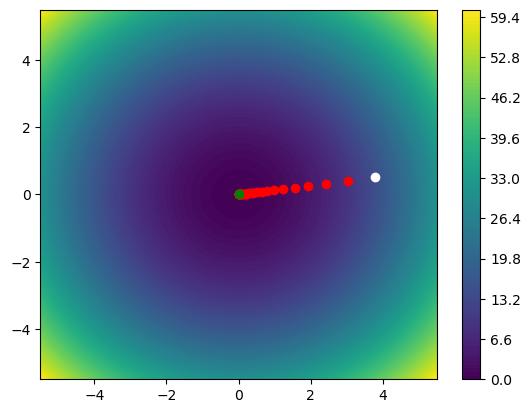

Solucion: [5.399115595250008e-05, 7.230571474211309e-06] 2.9673260849308628e-09


In [16]:
#Prepara los datos para dibujar mapa de niveles de Z
resolucion = 100
rango=5.5

X=np.linspace(-rango,rango,resolucion)
Y=np.linspace(-rango,rango,resolucion)
Z=np.zeros((resolucion,resolucion))
for ix,x in enumerate(X):
  for iy,y in enumerate(Y):
    Z[iy,ix] = f([x,y])

#Pinta el mapa de niveles de Z
plt.contourf(X,Y,Z,resolucion)
plt.colorbar()

#Generamos un punto aleatorio inicial y pintamos de blanco
P=[random.uniform(-5,5  ),random.uniform(-5,5 ) ]
plt.plot(P[0],P[1],"o",c="white")

#Tasa de aprendizaje. Fija. Sería más efectivo reducirlo a medida que nos acercamos.
TA=.1

#Iteraciones:50
for _ in range(50):
  grad = df(P)
  #print(P,grad)
  P[0],P[1] = P[0] - TA*grad[0] , P[1] - TA*grad[1]
  plt.plot(P[0],P[1],"o",c="red")

#Dibujamos el punto final y pintamos de verde
plt.plot(P[0],P[1],"o",c="green")
plt.show()
print("Solucion:" , P , f(P))


**¿Te atreves a optimizar la función?:**

$$f(x)=sin(1/2 * x^2 - 1/4 * y^2 + 3) * cos(2*x + 1 - e^y)$$
<br>
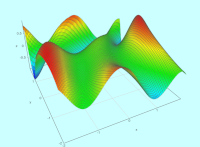


In [17]:
#Definimos la funcion
f = lambda X: math.sin(1/2 * X[0]**2 - 1/4 * X[1]**2 + 3) *math.cos(2*X[0] + 1 - math.exp(X[1]) )
df = lambda X: [
    math.cos(1/2*X[0]**2 - 1/4*X[1]**2 + 3) * X[0]        * math.cos(2*X[0] + 1 - math.exp(X[1]))
        - math.sin(1/2*X[0]**2 - 1/4*X[1]**2 + 3) * math.sin(2*X[0] + 1 - math.exp(X[1])) * 2,
    math.cos(1/2*X[0]**2 - 1/4*X[1]**2 + 3) * (-1/2*X[1]) * math.cos(2*X[0] + 1 - math.exp(X[1]))
        - math.sin(1/2*X[0]**2 - 1/4*X[1]**2 + 3) * math.sin(2*X[0] + 1 - math.exp(X[1])) * (-math.exp(X[1]))
]

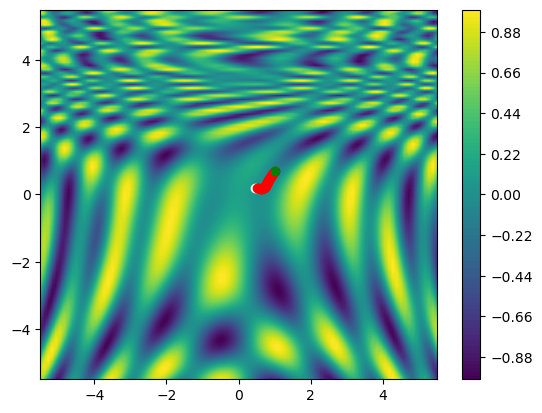

Solucion: [1.0011859266418646, 0.7013578986807795] -0.1294277163853799


In [18]:
#Prepara los datos para dibujar mapa de niveles de Z
resolucion = 100
rango=5.5

X=np.linspace(-rango,rango,resolucion)
Y=np.linspace(-rango,rango,resolucion)
Z=np.zeros((resolucion,resolucion))
for ix,x in enumerate(X):
  for iy,y in enumerate(Y):
    Z[iy,ix] = f([x,y])

#Pinta el mapa de niveles de Z
plt.contourf(X,Y,Z,resolucion)
plt.colorbar()

#Generamos un punto aleatorio inicial y pintamos de blanco
P=[random.uniform(-5,5  ),random.uniform(-5,5 ) ]
plt.plot(P[0],P[1],"o",c="white")

#Tasa de aprendizaje. Fija. Sería más efectivo reducirlo a medida que nos acercamos.
TA=.1

#Iteraciones:50
for _ in range(50):
  grad = df(P)
  #print(P,grad)
  P[0],P[1] = P[0] - TA*grad[0] , P[1] - TA*grad[1]
  plt.plot(P[0],P[1],"o",c="red")

#Dibujamos el punto final y pintamos de verde
plt.plot(P[0],P[1],"o",c="green")
plt.show()
print("Solucion:" , P , f(P))

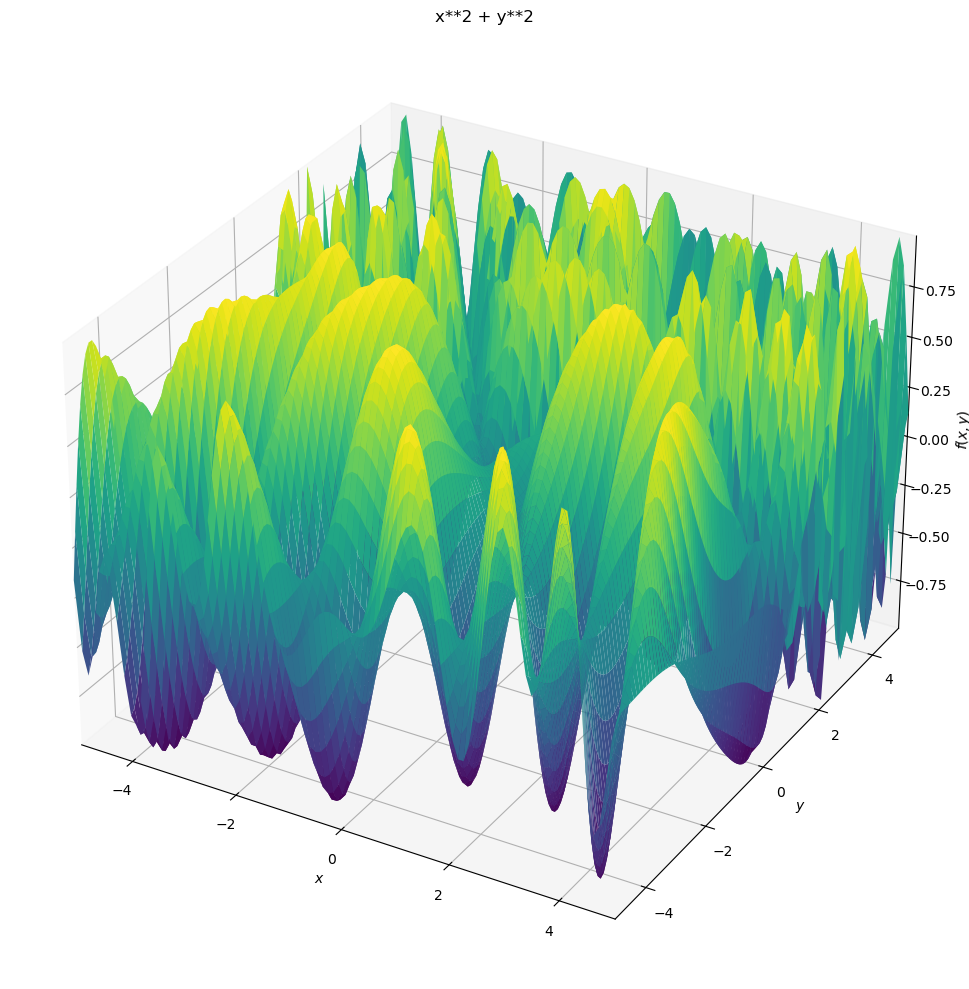

In [19]:
from sympy import symbols, sin, cos, exp
from sympy.plotting import plot
from sympy.plotting import plot3d
x,y = symbols('x y')
plot3d(sin(1/2 * x**2 - 1/4 * y**2 + 3) * cos(2*x + 1 - exp(y)),
       (x,-5,5),(y,-5,5),
       title='x**2 + y**2',
       size=(10,10))